In [1]:
import os, sys, time, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import networkx as nx
import psutil

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F

from torch_geometric.nn import GATConv
from sklearn.model_selection import KFold
from sklearn.metrics import mean_absolute_error
from scipy.stats import pearsonr
from scipy.spatial.distance import jensenshannon

warnings.filterwarnings('ignore')

if os.path.exists('/kaggle/input'):
    DATA_DIR = '/kaggle/input/datasets/guibmc/dgl-data'
    sys.path.append('/kaggle/input/datasets/guibmc/matrixvectorizer')
    KAGGLE = True
else:
    DATA_DIR = 'data'
    KAGGLE = False

from MatrixVectorizer import MatrixVectorizer

# Reproducibility
random_seed = 42
random.seed(random_seed)
np.random.seed(random_seed)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    device = torch.device('cuda')
    print('CUDA available — using GPU.')
    torch.cuda.manual_seed_all(random_seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
else:
    device = torch.device('cpu')
    print('CUDA not available — using CPU.')

CUDA available — using GPU.


LR Train : (167, 12720)
HR Train : (167, 35778)
LR Test  : (112, 12720)

LR[0]: symmetric=True  range=[0.000, 0.915]
HR[0]: symmetric=True  range=[0.000, 0.965]
HR non-zero edges: 79.5%  (zero: 20.5%)
HR mean (non-zero only): 0.3270


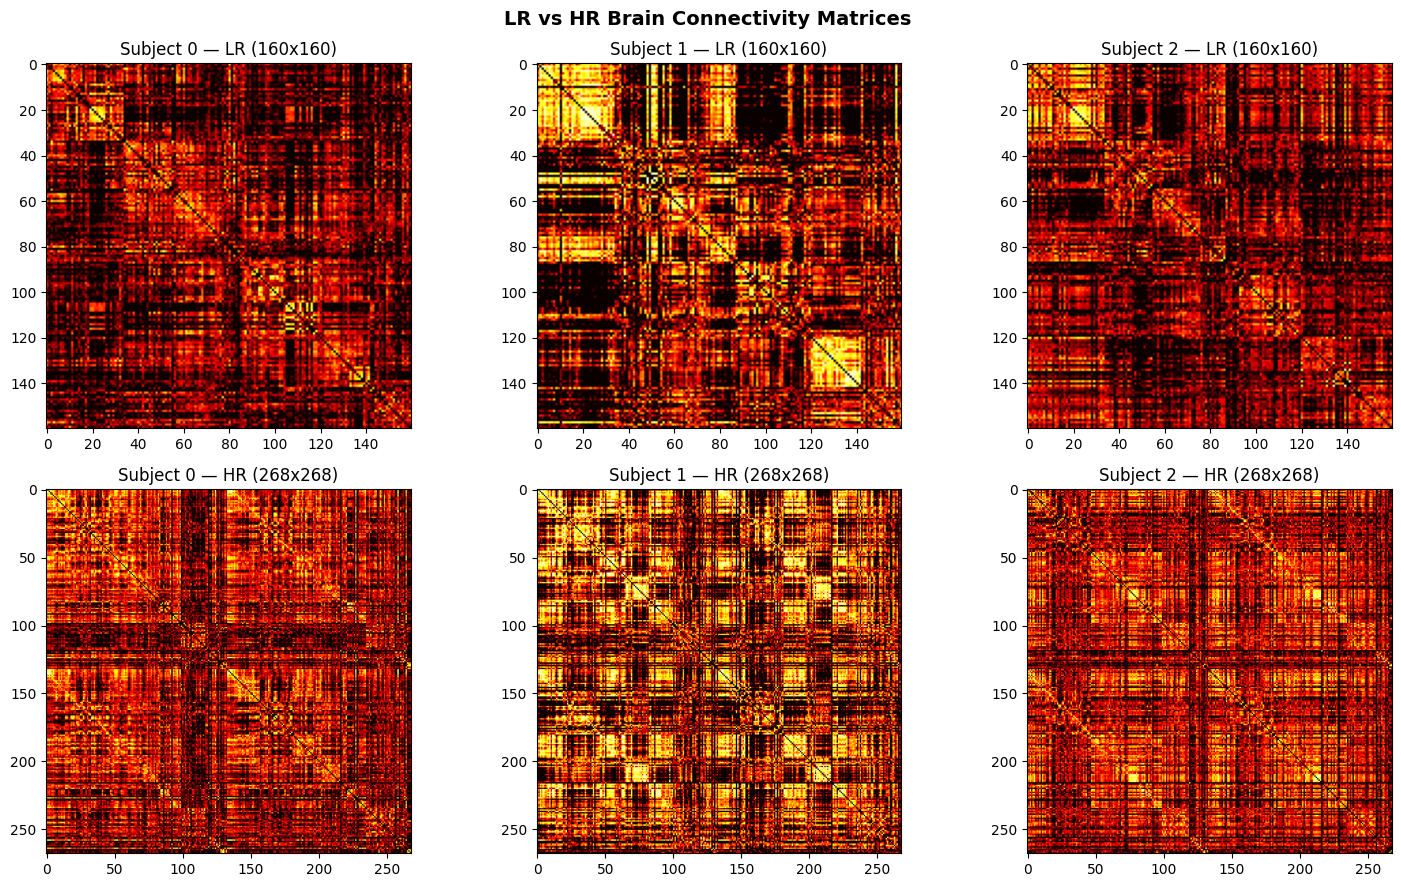

In [2]:
lr_train = pd.read_csv(os.path.join(DATA_DIR, 'lr_train.csv')).values.astype(np.float32)
hr_train = pd.read_csv(os.path.join(DATA_DIR, 'hr_train.csv')).values.astype(np.float32)
lr_test  = pd.read_csv(os.path.join(DATA_DIR, 'lr_test.csv')).values.astype(np.float32)

print(f'LR Train : {lr_train.shape}') # (167, 12720)
print(f'HR Train : {hr_train.shape}') # (167, 35778)
print(f'LR Test  : {lr_test.shape}') # (112, 12720)

# Replace negatives and NaNs with 0 (per spec)
lr_train = np.nan_to_num(np.clip(lr_train, 0, None))
hr_train = np.nan_to_num(np.clip(hr_train, 0, None))
lr_test  = np.nan_to_num(np.clip(lr_test,  0, None))

# Sanity check
N_LR = 160
N_HR = 268
N_LR_VEC = 12720
N_HR_VEC = 35778
lr_mat0 = MatrixVectorizer.anti_vectorize(lr_train[0], N_LR)
hr_mat0 = MatrixVectorizer.anti_vectorize(hr_train[0], N_HR)
print(f'\nLR[0]: symmetric={np.allclose(lr_mat0, lr_mat0.T)}  range=[{lr_mat0.min():.3f}, {lr_mat0.max():.3f}]')
print(f'HR[0]: symmetric={np.allclose(hr_mat0, hr_mat0.T)}  range=[{hr_mat0.min():.3f}, {hr_mat0.max():.3f}]')

hr_nonzero_pct = (hr_train > 0).mean() * 100
print(f'HR non-zero edges: {hr_nonzero_pct:.1f}%  (zero: {100-hr_nonzero_pct:.1f}%)')
print(f'HR mean (non-zero only): {hr_train[hr_train > 0].mean():.4f}')

# Visualise
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
for i in range(3):
    lm = MatrixVectorizer.anti_vectorize(lr_train[i], N_LR)
    hm = MatrixVectorizer.anti_vectorize(hr_train[i], N_HR)
    axes[0, i].imshow(lm, cmap='hot', vmin=0, vmax=1)
    axes[0, i].set_title(f'Subject {i} — LR (160x160)')
    axes[1, i].imshow(hm, cmap='hot', vmin=0, vmax=1)
    axes[1, i].set_title(f'Subject {i} — HR (268x268)')
plt.suptitle('LR vs HR Brain Connectivity Matrices', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [9]:
# pre-compute HR upper-triangle indices in column-major order to match
# MatrixVectorizer's vectorize() output exactly 
hr_rows, hr_cols = [], []
for c in range(N_HR):
    for r in range(c):
        hr_rows.append(r)
        hr_cols.append(c)
HR_ROWS = torch.tensor(hr_rows, dtype=torch.long)   # (35778,)
HR_COLS = torch.tensor(hr_cols, dtype=torch.long)   # (35778,)
assert len(HR_ROWS) == N_HR_VEC

def anti_vectorize_batch(vectors: np.ndarray, N: int) -> np.ndarray:
    return np.stack([MatrixVectorizer.anti_vectorize(v, N) for v in vectors])


def vectorize_batch(matrices: np.ndarray) -> np.ndarray:
    return np.stack([MatrixVectorizer.vectorize(m) for m in matrices])


def postprocess(pred_matrices: np.ndarray) -> np.ndarray:
    """Clamp negatives, zero diagonal, enforce symmetry."""
    pred_matrices = np.clip(pred_matrices, 0, None)
    for i in range(len(pred_matrices)):
        np.fill_diagonal(pred_matrices[i], 0)
        pred_matrices[i] = (pred_matrices[i] + pred_matrices[i].T) / 2
    return pred_matrices

THRESHOLD = 0.1

def adj_to_pyg(adj: np.ndarray, threshold: float = THRESHOLD):
    # drop weak edges so the graph isn't fully dense
    rows, cols = np.where(adj > threshold)
    edge_index = torch.tensor(np.stack([rows, cols]), dtype=torch.long)
    edge_weight = torch.tensor(adj[rows, cols], dtype=torch.float32)
    return edge_index, edge_weight

In [10]:
K_EIG = 16 

def compute_spectral_pe(adj: np.ndarray, k: int = K_EIG) -> np.ndarray:
    """
    Spectral positional encodings from the normalised graph Laplacian.
    L = I - D^{-1/2} A D^{-1/2}

    Take the top-k eigenvectors (skip the trivial all-ones one),
    normalise each to [-1, 1], and append to the node features.
    Computed per-subject from their own adjacency — fully inductive.

    Returns: (N_LR, k) float32
    """
    N = adj.shape[0]
    k = min(k, N - 2)
    
    # normalise by degree
    d = adj.sum(axis=1)
    d = np.where(d > 0, d, 1.0) # avoid div-by-zero for isolated nodes
    di = 1.0 / np.sqrt(d)
    L = np.eye(N) - (di[:, None] * adj * di[None, :])
    L = (L + L.T) / 2.0  # symmetrize numerically just in case
    
    _, eigvecs = np.linalg.eigh(L) # returns in ascending order
    pe = eigvecs[:, 1 : k + 1].astype(np.float32)   # skip trivial eigvec
    pe = pe / (np.abs(pe).max(axis=0, keepdims=True) + 1e-8)
    return pe


def build_node_features(adj: np.ndarray, pe: np.ndarray) -> torch.Tensor:
    """Concatenate adjacency rows (160) with SPE (K_EIG) to (160, 160+K_EIG)"""
    return torch.tensor(np.concatenate([adj, pe], axis=1), dtype=torch.float32)

pe0 = compute_spectral_pe(MatrixVectorizer.anti_vectorize(lr_train[0], N_LR))
print(f'SPE shape : {pe0.shape}  range=[{pe0.min():.3f}, {pe0.max():.3f}]')

SPE shape : (160, 16)  range=[-1.000, 1.000]


In [11]:
def degree_topology_loss(pred_vec : torch.Tensor, gt_vec : torch.Tensor, rows : torch.Tensor,
    cols : torch.Tensor, n_hr : int = N_HR,) -> torch.Tensor:
    """
    Computes per-node degree via scatter_addand returns L1 loss between predicted
    and GT degree vectors.

    In theory this should help the model get the right degree distribution,
    but in practice the loss scale (~17) is way too large compared to the
    reconstruction loss (~0.14) so training just diverges. Keeping it as
    an evaluation metric for now.
    """
    rows = rows.to(pred_vec.device)
    cols = cols.to(pred_vec.device)
    
    pred_deg = torch.zeros(n_hr, device=pred_vec.device)
    pred_deg.scatter_add_(0, rows, pred_vec)
    pred_deg.scatter_add_(0, cols, pred_vec)
    
    gt_deg = torch.zeros(n_hr, device=gt_vec.device)
    gt_deg.scatter_add_(0, rows, gt_vec)
    gt_deg.scatter_add_(0, cols, gt_vec)
    
    return F.l1_loss(pred_deg, gt_deg)

In [12]:
HIDDEN_DIM = 256   # GAT hidden dim
LATENT_DIM = 128   # Global graph embedding dim (after mean-pool)
GAT_HEADS = 4
POS_DIM = 64    # HR-node positional key dimension
MLP_DIM = 256   # Edge MLP hidden dim (Novel Contribution 2)
DROPOUT = 0.3

class SpecGSR(nn.Module):
    """
    SpecGSR: Spectral-Aware Neural Alignment for Brain Graph Super-Resolution.

    LR graph  (160 nodes, 176 features = 160 adj rows + 16 SPE)
      → 2-layer edge-weight-aware GAT encoder
      → mean-pool all 160 node embeddings
      → global_lr  (128-dim)   [subject-level LR context]

    Learnable HR positional keys: pos_hr  (268, 64)
      Each HR ROI gets a unique trainable vector — independent of LR features,
      so every HR node pair (i, j) produces a distinct decoder input.
      This is the main fix over v1, where a softmax assignment matrix collapsed
      all HR nodes into the same convex hull as LR nodes, making edge predictions
      nearly constant across the whole graph.

    For each upper-triangular HR edge (i, j):   [35,778 total]
      edge_input = [ pos_hr[i] | pos_hr[j] | global_lr ]   (256-dim)
      → 3-layer MLP → sigmoid → predicted edge weight ∈ (0, 1)
    """

    def __init__(self, n_lr : int = N_LR, n_hr : int = N_HR, k_eig : int = K_EIG,
        hidden_dim : int = HIDDEN_DIM, latent_dim : int = LATENT_DIM, heads : int = GAT_HEADS,
        pos_dim : int = POS_DIM, mlp_dim : int = MLP_DIM, dropout : float = DROPOUT,):
        
        super().__init__()
        self.n_lr = n_lr
        self.n_hr = n_hr

        in_dim = n_lr + k_eig # 160 + 16 = 176

        # two-layer GAT encoder. Uses edge weights as attention bias
        self.gat1  = GATConv(in_dim, hidden_dim // heads,
                             heads=heads, edge_dim=1, dropout=dropout, concat=True)
        self.norm1 = nn.LayerNorm(hidden_dim)

        self.gat2  = GATConv(hidden_dim, latent_dim,
                             heads=1, edge_dim=1, dropout=dropout, concat=False)
        self.norm2 = nn.LayerNorm(latent_dim)

        # one learnable vector per HR ROI. Also, xavier init gives good initial spread
        # so the decoder sees distinct inputs from the very first forward pass
        self.pos_hr = nn.Parameter(torch.empty(n_hr, pos_dim))
        nn.init.xavier_uniform_(self.pos_hr)

        # edge MLP: 2*64 + 128 = 256 in to hidden to 1
        edge_in = 2 * pos_dim + latent_dim 
        self.edge_mlp = nn.Sequential(
            nn.Linear(edge_in, mlp_dim),
            nn.LayerNorm(mlp_dim),
            nn.ELU(),
            nn.Dropout(dropout),
            nn.Linear(mlp_dim,  mlp_dim // 2),
            nn.LayerNorm(mlp_dim // 2),
            nn.ELU(),
            nn.Linear(mlp_dim // 2, 1),
            nn.Sigmoid(),
        )

        # register these so they move to GPU with .to(device) automatically
        self.register_buffer('tri_rows', HR_ROWS.clone())
        self.register_buffer('tri_cols', HR_COLS.clone())

    def encode_global(self, x, edge_index, edge_weight) -> torch.Tensor:
        """
        GAT encoder -> mean pool -> global subject-level LR embedding.
        Returns: (1, latent_dim)
        """
        ea = edge_weight.unsqueeze(-1)                              
        h = F.elu(self.norm1(self.gat1(x, edge_index, edge_attr=ea))) # (160, 256)
        h = F.elu(self.norm2(self.gat2(h, edge_index, edge_attr=ea))) # (160, 128)
        g = h.mean(dim=0, keepdim=True) # (1, 128)
        return g

    # ─────────────────────────────────────────────────────────────────────────
    def decode_edges(self, global_lr: torch.Tensor) -> torch.Tensor:
        """
        Predict all 35,778 upper-triangular HR edge weights.

        Each edge (i, j) gets a unique input: [pos_hr[i] | pos_hr[j] | global_lr]
        
        pos_hr[i] and pos_hr[j] differ for every ROI, so the decoder
        has enough information to produce distinct weights across the graph.
        global_lr carries the subject-specific LR context so predictions
        adapt per individual rather than collapsing to a fixed template.
        """
        pos_i = self.pos_hr[self.tri_rows] # (35778, 64)
        pos_j = self.pos_hr[self.tri_cols] # (35778, 64)

        # Broadcast global LR embedding to all 35,778 edges
        g_exp = global_lr.expand(self.tri_rows.shape[0], -1) # (35778, 128)

        feat = torch.cat([pos_i, pos_j, g_exp], dim=-1) # (35778, 256)

        pred = self.edge_mlp(feat) # (35778, 1)
        return pred.squeeze(-1) # (35778,)

    def forward(self, x, edge_index, edge_weight) -> torch.Tensor:
        g = self.encode_global(x, edge_index, edge_weight)
        pred = self.decode_edges(g)
        return pred


# quick check to make sure shapes are right before training
model = SpecGSR().to(device)
n_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'SpecGSR — trainable parameters: {n_params:,}')

# Shape smoke-test
adj0 = MatrixVectorizer.anti_vectorize(lr_train[0], N_LR)
pe0 = compute_spectral_pe(adj0)
x0 = build_node_features(adj0, pe0).to(device)
ei, ew = adj_to_pyg(adj0)
with torch.no_grad():
    out = model(x0, ei.to(device), ew.to(device))
print(f'Output shape: {out.shape}  expected: torch.Size([{N_HR_VEC}])  ✓')
print(f'Output range: [{out.min():.4f}, {out.max():.4f}]')
print(f'Output std: {out.std():.6f}  (>0.01 = discriminative, ~0 = constant)')
del model

SpecGSR — trainable parameters: 197,249
Output shape: torch.Size([35778])  expected: torch.Size([35778])  ✓
Output range: [0.2747, 0.7940]
Output std: 0.063027  (>0.01 = discriminative, ~0 = constant)


In [13]:
# Topology loss is NOT used in training (scale=17 overwhelms gradients).
# It is computed in evaluate_fold() as an evaluation metric only.
NONZERO_WEIGHT = 2.5 
SMOOTH_L1_BETA = 0.05

def weighted_reconstruction_loss(pred : torch.Tensor, target : torch.Tensor, nonzero_weight : float = NONZERO_WEIGHT,
    beta : float = SMOOTH_L1_BETA,) -> torch.Tensor:
    """
    SmoothL1 with heavier weight on non-zero edges.

    ~70% of HR edges are zero, so a naive loss just encourages the model
    to predict near-zero for everything. Upweighting the non-zero edges forces
    it to actually learn the connectivity pattern. Dividing by the sum of weights
    keeps the overall loss scale stable.
    """
    elem = F.smooth_l1_loss(pred, target, reduction='none', beta=beta)
    w = torch.ones_like(target)
    w[target > 0] = nonzero_weight
    return (elem * w).sum() / w.sum()

NUM_EPOCHS = 500 
LEARNING_RATE = 0.001
WEIGHT_DECAY = 1e-4
GRAD_CLIP = 1.0
COSINE_T0 = 100 # cosine annealing restart period

def train_model(lr_matrices : np.ndarray, hr_vectors : np.ndarray, num_epochs : int = NUM_EPOCHS,
    lr : float = LEARNING_RATE, nonzero_weight: float = NONZERO_WEIGHT, verbose : bool  = True,):
   
    model = SpecGSR().to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=WEIGHT_DECAY)
    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=COSINE_T0, T_mult=1, eta_min=1e-5
    )

    n_train = len(lr_matrices)

    # pre-compute SPE for all subjects upfront rather than recomputing every epoch
    print('  Pre-computing Spectral Positional Encodings...', end=' ', flush=True)
    all_pe = [compute_spectral_pe(adj) for adj in lr_matrices]
    print('done.')

    losses = []

    for epoch in range(num_epochs):
        model.train()
        epoch_mae = 0.0

        # shuffle subject order each epoch
        for idx in np.random.permutation(n_train):
            optimizer.zero_grad()

            lr_adj = lr_matrices[idx]
            x = build_node_features(lr_adj, all_pe[idx]).to(device)
            ei, ew = adj_to_pyg(lr_adj, THRESHOLD)
            target = torch.tensor(hr_vectors[idx], dtype=torch.float32).to(device)

            pred = model(x, ei.to(device), ew.to(device))
            loss = weighted_reconstruction_loss(pred, target, nonzero_weight)
            loss.backward()
            
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()

            with torch.no_grad():
                epoch_mae += F.l1_loss(pred, target).item()

        scheduler.step()
        avg_mae = epoch_mae / n_train
        losses.append(avg_mae)

        if verbose and (epoch + 1) % 20 == 0:
            print(f'Epoch [{epoch+1:3d}/{num_epochs}]  '
                  f'MAE: {avg_mae:.6f}  '
                  f'LR: {optimizer.param_groups[0]["lr"]:.2e}')

    return model, losses

In [14]:
def predict(model: SpecGSR, test_matrices: np.ndarray) -> np.ndarray:
    model.eval()
    preds = []
    with torch.no_grad():
        for adj in test_matrices:
            pe = compute_spectral_pe(adj)
            x = build_node_features(adj, pe).to(device)
            ei, ew = adj_to_pyg(adj, THRESHOLD)
            pred = model(x, ei.to(device), ew.to(device))
            preds.append(pred.cpu().numpy())
    return np.array(preds)


def evaluate_fold(pred_matrices: np.ndarray, gt_matrices: np.ndarray) -> dict:
    """
    Compute all 8 evaluation metrics.

    Standard (6): MAE, PCC, JSD, Betweenness MAE, Eigenvector MAE, PageRank MAE.
    Novel (2): Clustering Coefficient MAE, Graph Density MAE.
    """
    n = len(pred_matrices)
    mae_bc, mae_ec, mae_pc, mae_cc, mae_den = [], [], [], [], []
    pred_1d_list, gt_1d_list = [], []

    for i in range(n):
        P = nx.from_numpy_array(pred_matrices[i], edge_attr='weight')
        G = nx.from_numpy_array(gt_matrices[i],   edge_attr='weight')

        bc_p = nx.betweenness_centrality(P, weight='weight')
        bc_g = nx.betweenness_centrality(G, weight='weight')
        mae_bc.append(mean_absolute_error(list(bc_p.values()), list(bc_g.values())))

        try:
            ec_p = nx.eigenvector_centrality(P, weight='weight', max_iter=1000)
            ec_g = nx.eigenvector_centrality(G, weight='weight', max_iter=1000)
            mae_ec.append(mean_absolute_error(list(ec_p.values()), list(ec_g.values())))
        except Exception:
            # eigenvector centrality can fail to converge on near-disconnected graphs
            mae_ec.append(float('nan'))

        pc_p = nx.pagerank(P, weight='weight')
        pc_g = nx.pagerank(G, weight='weight')
        mae_pc.append(mean_absolute_error(list(pc_p.values()), list(pc_g.values())))

        # clustering coefficient, captures small-world / modular topology
        # pretty orthogonal to the centrality measures above
        mae_cc.append(abs(nx.average_clustering(P, weight='weight') -
                          nx.average_clustering(G, weight='weight')))

        # density, sensitive to over/under-predicting the number of present edges
        mae_den.append(abs(nx.density(P) - nx.density(G)))

        pred_1d_list.append(MatrixVectorizer.vectorize(pred_matrices[i]))
        gt_1d_list.append(MatrixVectorizer.vectorize(gt_matrices[i]))

    pred_1d = np.concatenate(pred_1d_list)
    gt_1d = np.concatenate(gt_1d_list)

    return {
        'MAE' : mean_absolute_error(pred_1d, gt_1d),
        'PCC' : pearsonr(pred_1d, gt_1d)[0],
        'JSD' : jensenshannon(pred_1d, gt_1d),
        'Betweenness MAE' : np.nanmean(mae_bc),
        'Eigenvector MAE' : np.nanmean(mae_ec),
        'PageRank MAE' : np.nanmean(mae_pc),
        'Clustering Coeff MAE' : np.nanmean(mae_cc),
        'Density MAE' : np.nanmean(mae_den),
    }

In [15]:
METRIC_COLORS = ['#E74C3C',"#0C8C41","#5929C1", '#F39C12', "#35D5F1","#5DF18C"]

PLOT_METRICS = [
    ('MAE', 'MAE'),
    ('PCC', 'PCC'),
    ('JSD', 'JSD'),
    ('PageRank MAE', 'MAE (PC)'),
    ('Eigenvector MAE', 'MAE (EC)'),
    ('Betweenness MAE', 'MAE (BC)'),
]

def plot_cv_results(all_fold_metrics: list, save_path: str = 'cv_barplots.png'):
    keys   = [k for k, _ in PLOT_METRICS]   # internal dict keys
    labels = [l for _, l in PLOT_METRICS]   # display labels
    
    n_folds = len(all_fold_metrics)
    x, bar_w = np.arange(len(keys)), 0.6
    fig, axes = plt.subplots(2, 2, figsize=(18, 12))
    axes = axes.flatten()

    for fi in range(n_folds):
        ax = axes[fi]
        v = [all_fold_metrics[fi][m] for m in keys]
        bars = ax.bar(x, v, width=bar_w, color=METRIC_COLORS, edgecolor='white', lw=0.8)
        ax.set_title(f'Fold {fi+1}', fontsize=14, fontweight='bold')
        ax.set_xticks(x)
        ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
        ax.set_ylim(0, max(v) * 1.28)
        ax.set_ylabel('Score')
        ax.grid(axis='y', linestyle='--', alpha=0.35)
        for bar, val in zip(bars, v):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + 0.004,
                    f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

    ax = axes[3]
    means = [np.mean([fm[m] for fm in all_fold_metrics]) for m in keys]
    stds = [np.std( [fm[m] for fm in all_fold_metrics]) for m in keys]
    bars = ax.bar(x, means, width=bar_w, color=METRIC_COLORS, edgecolor='white', lw=0.8)
    ax.errorbar(x, means, yerr=stds, fmt='none', color='black', capsize=5, lw=2)
    ax.set_title('Avg. Across Folds ± Std', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(labels, rotation=30, ha='right', fontsize=9)
    ax.set_ylim(0, max(m+s for m,s in zip(means, stds)) * 1.35)
    ax.set_ylabel('Score')
    ax.grid(axis='y', linestyle='--', alpha=0.35)
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 0.004,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7.5)

    fig.suptitle('SpecGSR — 3-Fold CV Evaluation',
                 fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Bar plot saved → {save_path}')


def save_fold_csv(pred_vectors: np.ndarray, fold_num: int, out_dir: str = '.'):
    flat = pred_vectors.flatten()
    df = pd.DataFrame({'ID': np.arange(1, len(flat)+1), 'Predicted': flat})
    path = os.path.join(out_dir, f'predictions_fold_{fold_num}.csv')
    df.to_csv(path, index=False)
    print(f'  Saved {path}  ({len(df):,} rows)')


def save_submission_csv(pred_vectors: np.ndarray, out_dir: str = '.'):
    flat = pred_vectors.flatten()
    df = pd.DataFrame({'ID': np.arange(1, len(flat)+1), 'Predicted': flat})
    path = os.path.join(out_dir, 'submission.csv')
    df.to_csv(path, index=False)
    print(f'  Kaggle submission → {path}  ({len(df):,} rows)')

In [16]:
print('Anti-vectorizing...')
lr_train_mats = anti_vectorize_batch(lr_train, N_LR)   # (167, 160, 160)
hr_train_mats = anti_vectorize_batch(hr_train, N_HR)   # (167, 268, 268)
lr_test_mats  = anti_vectorize_batch(lr_test,  N_LR)   # (112, 160, 160)
print(f'LR train: {lr_train_mats.shape}')
print(f'HR train: {hr_train_mats.shape}')
print(f'LR test : {lr_test_mats.shape}')

Anti-vectorizing...
LR train: (167, 160, 160)
HR train: (167, 268, 268)
LR test : (112, 160, 160)


In [17]:
print('=== Architecture Sanity Check (untrained model) ===')
model = SpecGSR().to(device)
model.eval()
with torch.no_grad():
    adj0 = lr_train_mats[0]
    pe0 = compute_spectral_pe(adj0)
    x0 = build_node_features(adj0, pe0).to(device)
    ei,ew = adj_to_pyg(adj0)
    pred0 = model(x0, ei.to(device), ew.to(device)).cpu().numpy()

    adj1 = lr_train_mats[1]
    pe1 = compute_spectral_pe(adj1)
    x1 = build_node_features(adj1, pe1).to(device)
    ei1,ew1 = adj_to_pyg(adj1)
    pred1 = model(x1, ei1.to(device), ew1.to(device)).cpu().numpy()

print(f'Subj 0 pred  — mean: {pred0.mean():.4f}  std: {pred0.std():.4f}  '
      f'min: {pred0.min():.4f}  max: {pred0.max():.4f}')
print(f'Subj 1 pred  — mean: {pred1.mean():.4f}  std: {pred1.std():.4f}  '
      f'min: {pred1.min():.4f}  max: {pred1.max():.4f}')
print(f'Cross-subject diff  — mean |Δ|: {np.abs(pred0 - pred1).mean():.4f}')
print()
print('Checks:')
print(f'  std > 0.01  (discriminative output)  : {pred0.std() > 0.01}')
print(f'  cross-subj diff > 0  (subject-specific) : {np.abs(pred0 - pred1).mean() > 1e-6}')
del model

=== Architecture Sanity Check (untrained model) ===
Subj 0 pred  — mean: 0.6810  std: 0.0102  min: 0.6375  max: 0.7186
Subj 1 pred  — mean: 0.6958  std: 0.0090  min: 0.6574  max: 0.7271
Cross-subject diff  — mean |Δ|: 0.0148

Checks:
  std > 0.01  (discriminative output)  : True
  cross-subj diff > 0  (subject-specific) : True


In [18]:
kf = KFold(n_splits=3, shuffle=True, random_state=random_seed)

all_fold_metrics = []
start_time = time.time()
start_ram  = psutil.Process(os.getpid()).memory_info().rss / 1e6

for fold_num, (train_idx, val_idx) in enumerate(kf.split(lr_train_mats), 1):
    print(f'\n{"="*58}')
    print(f'  FOLD {fold_num}   Train: {len(train_idx)}   Val: {len(val_idx)}')
    print(f'{"="*58}')

    model, losses = train_model(
        lr_matrices = lr_train_mats[train_idx],
        hr_vectors  = hr_train[train_idx],
        num_epochs  = NUM_EPOCHS,
        lr          = LEARNING_RATE,
    )

    pred_vecs = predict(model, lr_train_mats[val_idx])
    pred_mats = postprocess(anti_vectorize_batch(pred_vecs, N_HR))

    metrics = evaluate_fold(pred_mats, hr_train_mats[val_idx])
    all_fold_metrics.append(metrics)

    print(f'\n  Fold {fold_num} Results:')
    for k, v in metrics.items():
        print(f'    {k:<25s}: {v:.6f}')

    save_fold_csv(vectorize_batch(pred_mats), fold_num)

total_time = time.time() - start_time
end_ram = psutil.Process(os.getpid()).memory_info().rss / 1e6

print(f'\n{"="*58}')
print(f'  Total time : {total_time:.1f}s  ({total_time/60:.1f} min)')
print(f'  RAM usage  : {end_ram:.0f} MB  (Δ {end_ram-start_ram:+.0f} MB)')
print(f'{"="*58}')

# Summary table
metric_names = list(all_fold_metrics[0].keys())
print(f"\n  {'Metric':<25}  {'F1':>8}  {'F2':>8}  {'F3':>8}  {'Avg':>8}  {'Std':>8}")
print(f"  {'-'*70}")
for m in metric_names:
    vals = [fm[m] for fm in all_fold_metrics]
    print(f"  {m:<25}  "
          + '  '.join(f'{v:8.5f}' for v in vals)
          + f'  {np.mean(vals):8.5f}  {np.std(vals):8.5f}')


  FOLD 1   Train: 111   Val: 56
  Pre-computing Spectral Positional Encodings... 

done.
Epoch [ 20/500]  MAE: 0.168785  LR: 9.05e-04
Epoch [ 40/500]  MAE: 0.153073  LR: 6.58e-04
Epoch [ 60/500]  MAE: 0.145670  LR: 3.52e-04
Epoch [ 80/500]  MAE: 0.141800  LR: 1.05e-04
Epoch [100/500]  MAE: 0.140469  LR: 1.00e-03
Epoch [120/500]  MAE: 0.141507  LR: 9.05e-04
Epoch [140/500]  MAE: 0.137859  LR: 6.58e-04
Epoch [160/500]  MAE: 0.133711  LR: 3.52e-04
Epoch [180/500]  MAE: 0.130469  LR: 1.05e-04
Epoch [200/500]  MAE: 0.129442  LR: 1.00e-03
Epoch [220/500]  MAE: 0.135145  LR: 9.05e-04
Epoch [240/500]  MAE: 0.132749  LR: 6.58e-04
Epoch [260/500]  MAE: 0.129291  LR: 3.52e-04
Epoch [280/500]  MAE: 0.127206  LR: 1.05e-04
Epoch [300/500]  MAE: 0.126348  LR: 1.00e-03
Epoch [320/500]  MAE: 0.131627  LR: 9.05e-04
Epoch [340/500]  MAE: 0.131551  LR: 6.58e-04
Epoch [360/500]  MAE: 0.127431  LR: 3.52e-04
Epoch [380/500]  MAE: 0.126020  LR: 1.05e-04
Epoch [400/500]  MAE: 0.125221  LR: 1.00e-03
Epoch [420/500]  MAE: 0.130769  LR: 9.05e-04
Epoch [440/500]  MAE: 0.129202  LR: 6.58e-04
Epoc

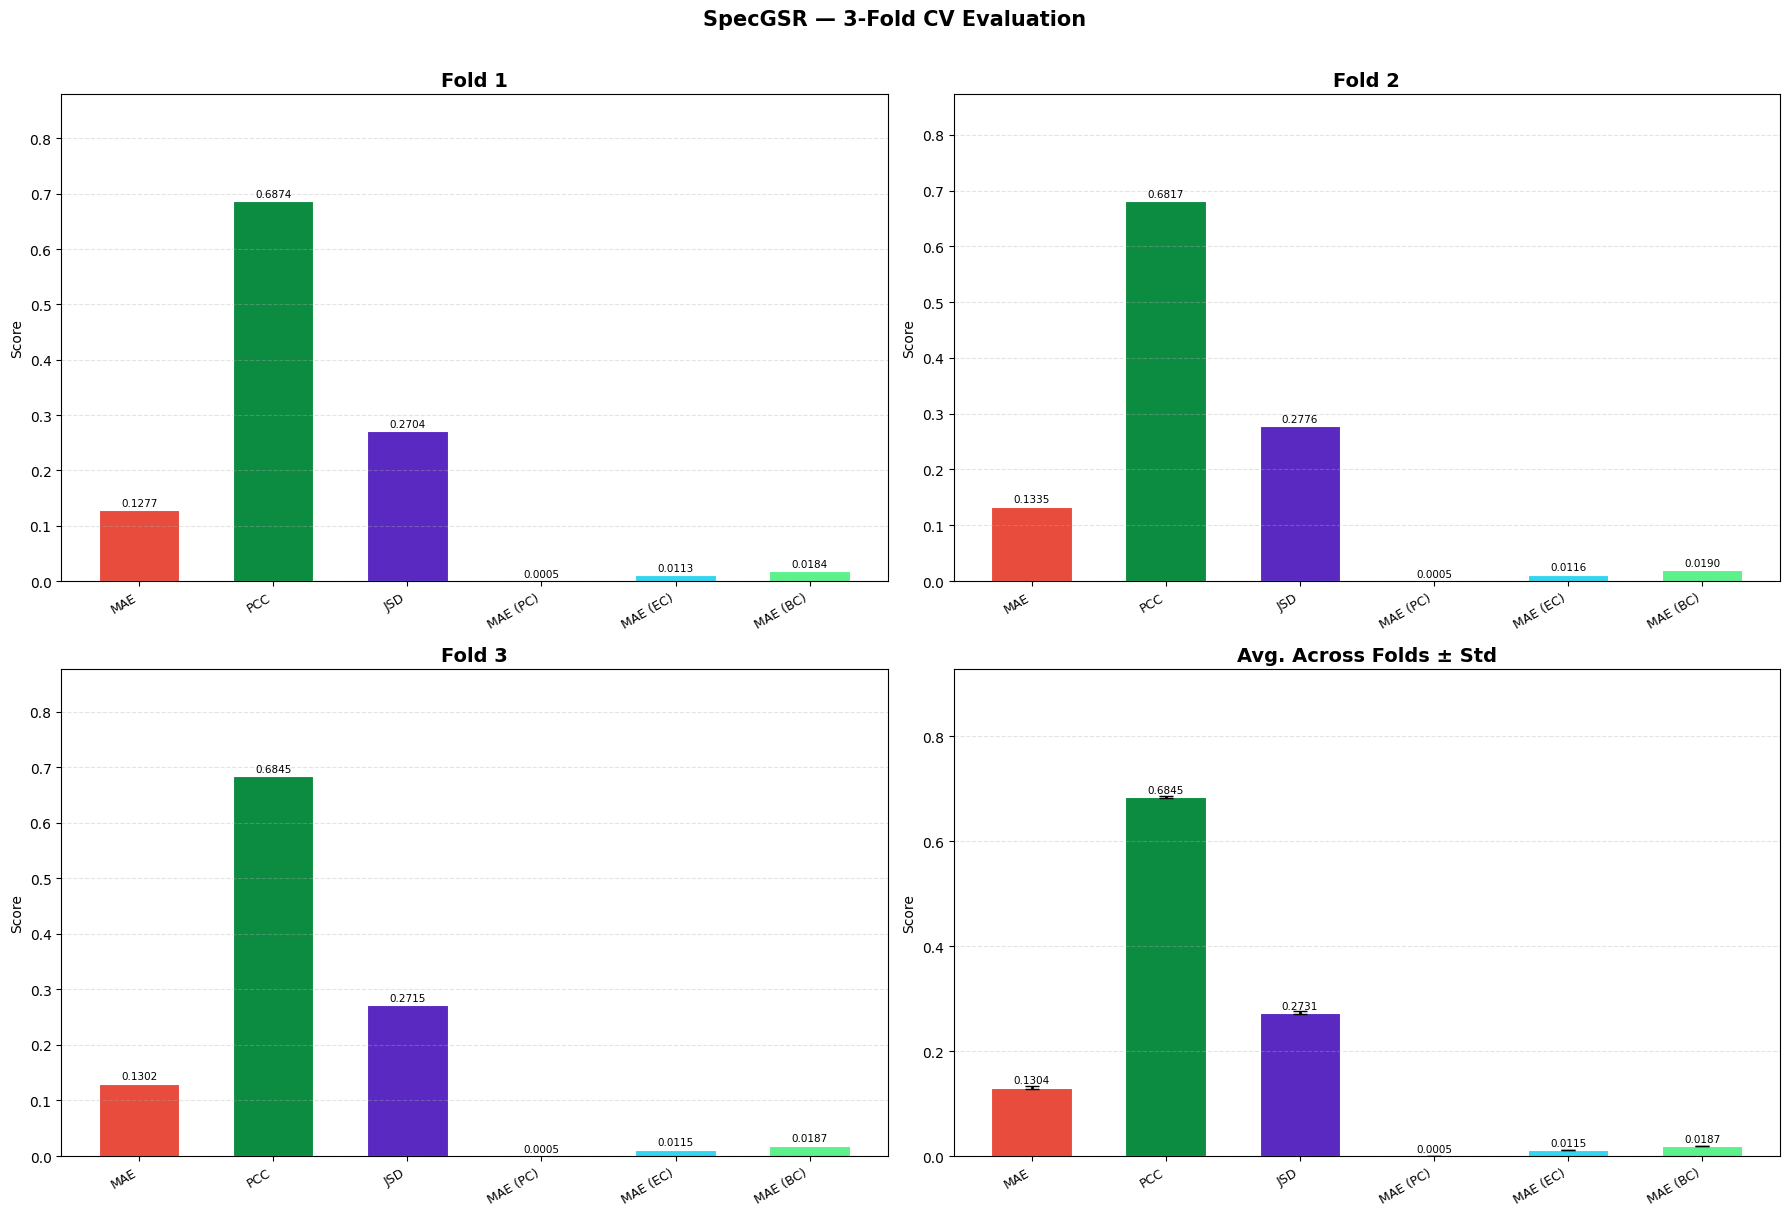

Bar plot saved → cv_barplots.png


In [19]:
plot_cv_results(all_fold_metrics, save_path='cv_barplots.png')

Full retrain on all 167 training subjects...
  Pre-computing Spectral Positional Encodings... done.
Epoch [ 20/500]  MAE: 0.152341  LR: 9.05e-04
Epoch [ 40/500]  MAE: 0.142448  LR: 6.58e-04
Epoch [ 60/500]  MAE: 0.136006  LR: 3.52e-04
Epoch [ 80/500]  MAE: 0.131677  LR: 1.05e-04
Epoch [100/500]  MAE: 0.130051  LR: 1.00e-03
Epoch [120/500]  MAE: 0.133634  LR: 9.05e-04
Epoch [140/500]  MAE: 0.131478  LR: 6.58e-04
Epoch [160/500]  MAE: 0.129446  LR: 3.52e-04
Epoch [180/500]  MAE: 0.127037  LR: 1.05e-04
Epoch [200/500]  MAE: 0.126003  LR: 1.00e-03
Epoch [220/500]  MAE: 0.132147  LR: 9.05e-04
Epoch [240/500]  MAE: 0.129236  LR: 6.58e-04
Epoch [260/500]  MAE: 0.127457  LR: 3.52e-04
Epoch [280/500]  MAE: 0.125521  LR: 1.05e-04
Epoch [300/500]  MAE: 0.124648  LR: 1.00e-03
Epoch [320/500]  MAE: 0.130904  LR: 9.05e-04
Epoch [340/500]  MAE: 0.128417  LR: 6.58e-04
Epoch [360/500]  MAE: 0.126161  LR: 3.52e-04
Epoch [380/500]  MAE: 0.125025  LR: 1.05e-04
Epoch [400/500]  MAE: 0.124248  LR: 1.00e-03


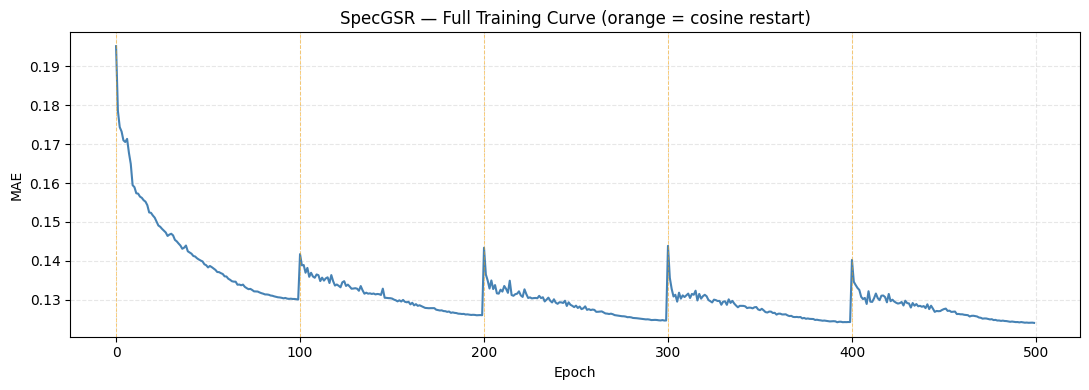

Done.


In [20]:
print('Full retrain on all 167 training subjects...')
final_model, final_losses = train_model(
    lr_matrices = lr_train_mats,
    hr_vectors = hr_train,
    num_epochs = NUM_EPOCHS,
    lr = LEARNING_RATE,
)

print('\nPredicting on 112 test subjects...')
test_vecs = predict(final_model, lr_test_mats)
test_mats = postprocess(anti_vectorize_batch(test_vecs, N_HR))
save_submission_csv(vectorize_batch(test_mats))

plt.figure(figsize=(11, 4))
plt.plot(final_losses, color='steelblue', lw=1.5)
for r in range(0, NUM_EPOCHS, COSINE_T0):
    plt.axvline(r, color='orange', lw=0.7, linestyle='--', alpha=0.5)
plt.xlabel('Epoch'); plt.ylabel('MAE')
plt.title('SpecGSR — Full Training Curve (orange = cosine restart)')
plt.grid(linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=150)
plt.show()
print('Done.')